# SHAP Explorer — อ่านผลของงานทั้งหมดในที่เดียว

notebook นี้เล่าเรื่องตามลำดับคำถาม 4 ข้อ:

| ส่วน | คำถาม |
|---|---|
| **A** | XGBoost แยก attack แต่ละชนิดโดยดูจากฟีเจอร์ไหน ให้น้ำหนักเท่าไหร่ |
| **B** | มีวิธีรวมฟีเจอร์แบบไหนบ้าง แต่ละแบบได้กี่ตัว |
| **C** | เอาไปเทรน stage 1 แล้วผลเป็นไง แม่นแค่ไหน เร็วแค่ไหน |
| **D** | อ่านกราฟ SHAP ยังไง |

### ⚠️ notebook นี้ไม่ผลิตผลการทดลอง

ตัวเลขในรายงานมาจาก `.py` เท่านั้น ที่นี่แค่เอามา**แสดงให้อ่านง่าย**

- ตรรกะ `import` มาจาก `03_shap_features.py` — ไม่ได้ก๊อปโค้ด
- ผลลัพธ์อ่านจาก `outputs/*.csv` ที่ `04`/`05` สร้างไว้ — ไม่คำนวณใหม่

→ แก้ `.py` ที่เดียว notebook ได้ของใหม่อัตโนมัติ

### ต้องรันก่อน
```
python 01_prepare_data.py
python 02_train_stage2.py
python 03_shap_features.py
python 04_train_stage1.py
python 05_zero_shot.py
```
แล้วเลือก kernel `.venv` ที่มุมขวาบน

In [16]:
import json
from importlib import import_module

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

import common, config

# ฟอนต์เริ่มต้นของ matplotlib ไม่มีตัวอักษรไทย ข้อความจะกลายเป็นสี่เหลี่ยม
# Thonburi เป็นฟอนต์ไทยที่ติดมากับ macOS อยู่แล้ว (Sarabun matplotlib โหลดไม่ได้)
# ใส่เป็น list เพื่อให้ matplotlib fallback ไป DejaVu Sans เวลาเจอตัวอักษร
# ที่ Thonburi ไม่มี (เช่นเครื่องหมายลบใน 10^-1 ของแกน log)
plt.rcParams['font.family'] = ['Thonburi', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ชื่อไฟล์ขึ้นต้นด้วยตัวเลข จึงใช้ `import 03_shap_features` ตรง ๆ ไม่ได้
m3 = import_module("03_shap_features")

df = common.load_clean()
model, le, X_train, X_test, y_train, y_test = m3.load_variant(df, "attack_only")
imp = m3.shap_importance(model, X_train, list(le.classes_), "attack_only")

print(f"\nโมเดล stage 2: {type(model).__name__} | {len(le.classes_)} คลาส")
print(f"ตาราง importance: {imp.shape[0]} ฟีเจอร์ × {imp.shape[1]} คลาส")


คำนวณ SHAP — attack_only
  subsample 5,000 แถวจาก train set (220,372 แถว)


XGBoostError: [21:11:43] /Users/runner/work/xgboost/xgboost/src/learner.cc:1310: Check failed: learner_model_param_.num_feature >= p_fmat->Info().num_col_ (65 vs. 67) : Number of columns does not match number of features in booster.
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x0000000116d156ec dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x0000000116f95cc0 xgboost::LearnerImpl::ValidateDMatrix(xgboost::DMatrix*, bool) const + 452
  [bt] (2) 3   libxgboost.dylib                    0x0000000116f85730 xgboost::LearnerImpl::Predict(std::__1::shared_ptr<xgboost::DMatrix>, bool, xgboost::HostDeviceVector<float>*, int, int, bool, bool, bool, bool, bool, bool) + 388
  [bt] (3) 4   libxgboost.dylib                    0x0000000116da1380 XGBoosterPredictFromDMatrix + 876
  [bt] (4) 5   libffi.dylib                        0x00000001afd79050 ffi_call_SYSV + 80
  [bt] (5) 6   libffi.dylib                        0x00000001afd8

---
# ส่วน A — attack แต่ละชนิดดูจากฟีเจอร์ไหน

## A1. Top 8 ฟีเจอร์ของแต่ละ attack

ตัวเลขคือสัดส่วนความสำคัญ (normalize ให้แต่ละคลาสรวม = 1)
เช่น 0.53 แปลว่าฟีเจอร์นี้กินความสำคัญ 53% ของการตัดสินใจทั้งหมดของคลาสนั้น

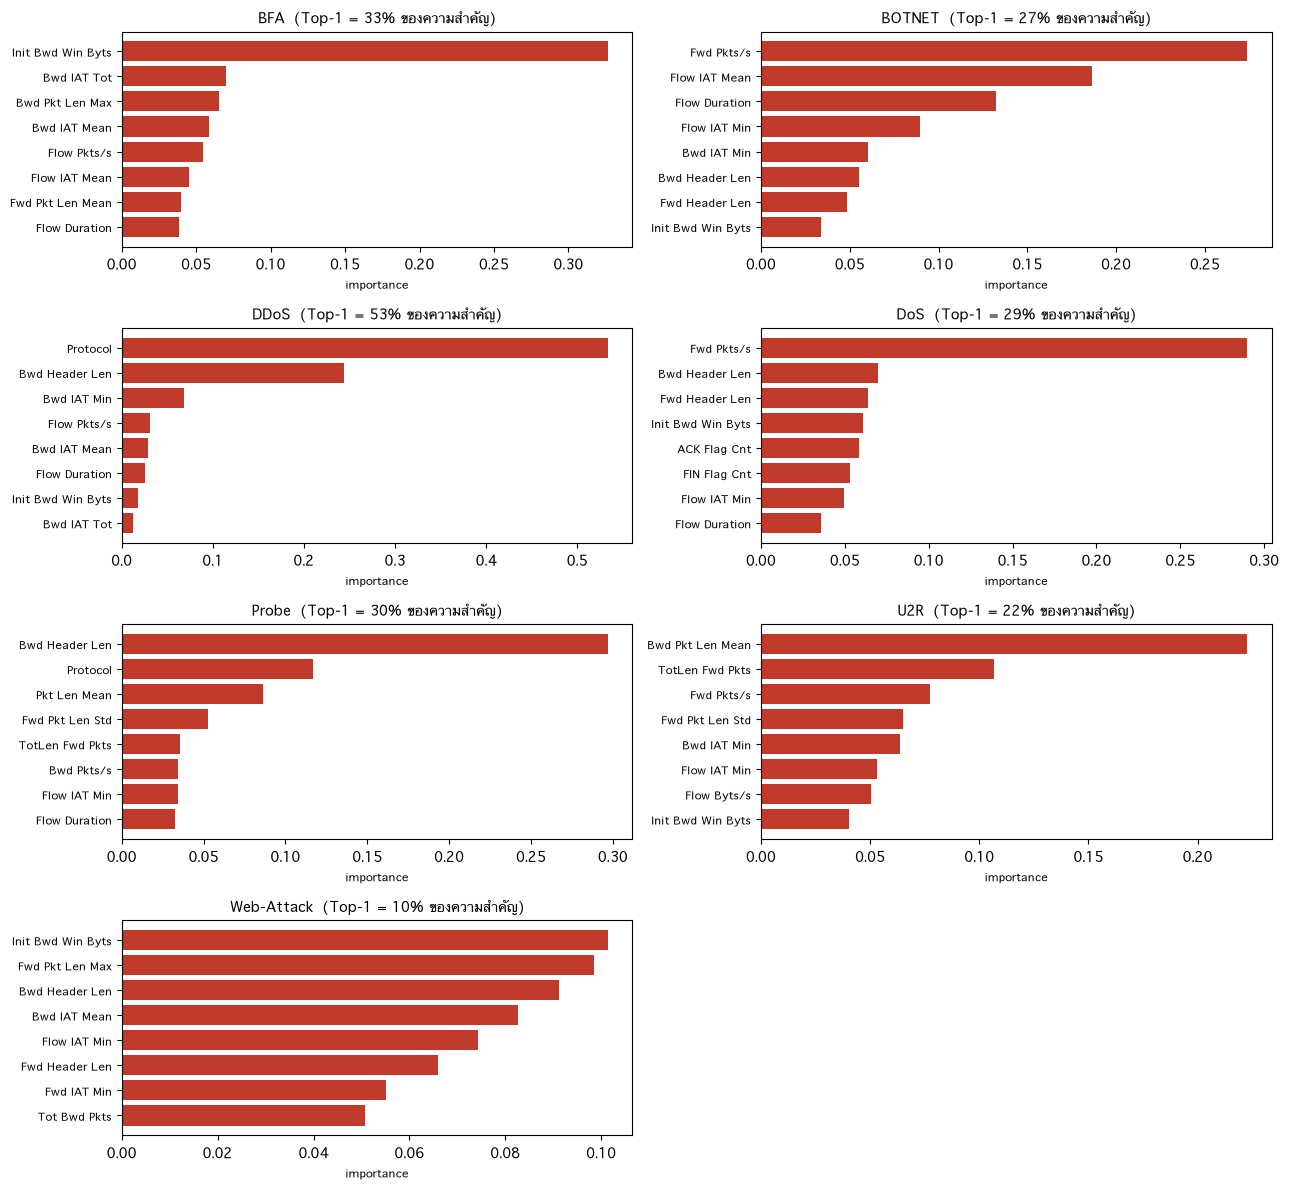

In [ ]:
n_cls = len(imp.columns)
fig, axes = plt.subplots((n_cls + 1) // 2, 2, figsize=(13, 3 * ((n_cls + 1) // 2)))

for ax, cls in zip(axes.ravel(), imp.columns):
    top = imp[cls].nlargest(8).sort_values()
    ax.barh(range(len(top)), top.values, color='#c0392b')
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top.index, fontsize=8)
    ax.set_title(f"{cls}  (Top-1 = {top.values[-1]:.0%} ของความสำคัญ)", fontsize=10)
    ax.set_xlabel("importance", fontsize=8)

for ax in axes.ravel()[n_cls:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'top_features_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

**อ่านกราฟชุดนี้:** ชื่อฟีเจอร์ในแต่ละกล่องไม่เหมือนกัน
= XGBoost ใช้หลักฐานคนละอย่างในการชี้ว่าเป็น attack ชนิดไหน

**นี่คือต้นตอของปัญหาที่อาจารย์ตั้งไว้** — ถ้าทุกคลาสใช้ฟีเจอร์เดียวกันหมด
ก็ไม่มีอะไรต้องถกเถียงเรื่องวิธีรวม

In [ ]:
# ตารางเต็ม — เอาเฉพาะฟีเจอร์ที่ติด Top-10 ของคลาสใดคลาสหนึ่ง
top_union = set()
for c in imp.columns:
    top_union |= set(imp[c].nlargest(10).index)

view = imp.loc[sorted(top_union)].sort_values(imp.columns[0], ascending=False)
print(f"{len(view)} ฟีเจอร์ที่ติด Top-10 ของอย่างน้อย 1 คลาส (จากทั้งหมด {len(imp)} ตัว)")
display(view.style.background_gradient(axis=0, cmap='Reds').format('{:.4f}'))

30 ฟีเจอร์ที่ติด Top-10 ของอย่างน้อย 1 คลาส (จากทั้งหมด 65 ตัว)


,BFA,BOTNET,DDoS,DoS,Probe,U2R,Web-Attack
Init Bwd Win Byts,0.3266,0.0340,0.0174,0.0609,0.0291,0.0401,0.1014
Bwd IAT Tot,0.0699,0.0042,0.0125,0.0056,0.0182,0.0000,0.0094
Bwd Pkt Len Max,0.0655,0.0000,0.0000,0.0017,0.0000,0.0255,0.0155
Bwd IAT Mean,0.0585,0.0000,0.0285,0.0012,0.0113,0.0000,0.0826
Flow Pkts/s,0.0549,0.0000,0.0307,0.0090,0.0148,0.0000,0.0233
Flow IAT Mean,0.0452,0.1864,0.0026,0.0112,0.0096,0.0000,0.0093
Fwd Pkt Len Mean,0.0399,0.0050,0.0000,0.0226,0.0025,0.0082,0.0065
Flow Duration,0.0384,0.1324,0.0259,0.0356,0.0327,0.0122,0.0031
Bwd Pkts/s,0.0379,0.0000,0.0000,0.0174,0.0343,0.0249,0.0023
Bwd IAT Std,0.0337,0.0000,0.0000,0.0016,0.0096,0.0041,0.0000


---
# ส่วน B — วิธีรวมฟีเจอร์

## B1. Dynamic-K — แต่ละคลาสต้องใช้กี่ฟีเจอร์

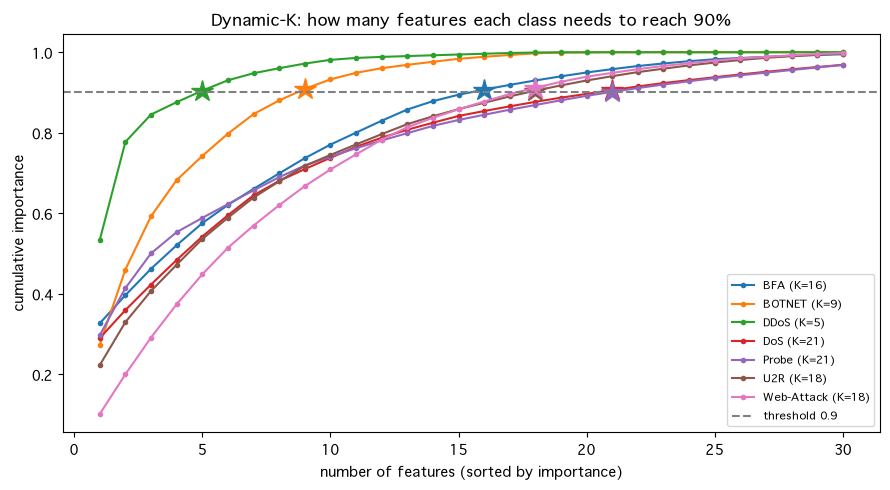

เส้นชันเร็ว = ตัดสินใจด้วยฟีเจอร์ไม่กี่ตัว  (ดาว = จุดที่หยุดเก็บ)


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

for c in imp.columns:
    cum = imp[c].sort_values(ascending=False).cumsum().values
    k = int((cum < config.CUMULATIVE_THRESHOLD).sum()) + 1
    ax.plot(range(1, 31), cum[:30], marker='o', ms=3, label=f"{c} (K={k})")
    ax.plot(k, cum[k-1], marker='*', ms=16, color=ax.lines[-1].get_color())

ax.axhline(config.CUMULATIVE_THRESHOLD, ls='--', c='gray',
           label=f"threshold {config.CUMULATIVE_THRESHOLD}")
ax.set_xlabel("number of features (sorted by importance)")
ax.set_ylabel("cumulative importance")
ax.set_title("Dynamic-K: how many features each class needs to reach 90%")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'dynamic_k_cumulative.png', dpi=150, bbox_inches='tight')
plt.show()

print("เส้นชันเร็ว = ตัดสินใจด้วยฟีเจอร์ไม่กี่ตัว  (ดาว = จุดที่หยุดเก็บ)")

## B2. ชุดฟีเจอร์แต่ละแบบคืออะไร มายังไง

การสร้างชุดฟีเจอร์ 1 ชุด ต้องตัดสินใจ **2 ขั้น**:

```
ขั้นที่ 1  เลือกว่าจะเอา SHAP มาจากโมเดลไหน   →  ได้ตาราง imp
ขั้นที่ 2  เลือกว่าจะยุบตาราง imp ยังไง        →  ได้รายชื่อฟีเจอร์
```

ตาราง `imp` ที่ได้จากขั้นที่ 1 หน้าตาแบบนี้ (ค่า normalize ให้แต่ละคอลัมน์รวม = 1):

```
                    BFA   BOTNET   DDoS    DoS   Probe   U2R    Web
Protocol           0.002   0.000   0.534  0.000  0.117  0.000  0.000
Bwd Header Len     0.028   0.054   0.245  0.065  0.298  0.019  0.091
Init Bwd Win Byts  0.325   0.033   0.011  0.056  0.014  0.040  0.101
...                                                     (65 แถว × 7 คอลัมน์)
```

**ปัญหาคือ:** เราต้องการ *รายชื่อฟีเจอร์ชุดเดียว* ไปเทรน stage 1
แต่ตารางนี้มี 7 คอลัมน์ — แต่ละคลาสบอกไม่เหมือนกัน จะยุบยังไง?

---

### วิธีที่ 1 — `union` (รวมทุกคลาส)

```python
top_per_class = {c: set(imp[c].nlargest(15).index) for c in imp.columns}
union = set().union(*top_per_class.values())
```

หา Top-15 ของแต่ละคลาสแยกกัน (ได้ 7 ชุด) แล้วเทกองรวมกัน
**ติด Top-15 ของคลาสไหนก็เอาหมด**

| | |
|---|---|
| ได้ | **37 ตัว** (จาก 7×15 = 105 ช่อง แต่ซ้ำกันเยอะ) |
| ข้อดี | ไม่พลาดฟีเจอร์ที่สำคัญเฉพาะบางคลาส |
| ข้อเสีย | ฟีเจอร์บวม และตัวที่สำคัญเฉพาะคลาสเล็กกลายเป็น noise สำหรับคลาสใหญ่ |

---

### วิธีที่ 2 — `intersection` (เอาเฉพาะที่ทุกคลาสเห็นตรงกัน)

```python
inter = set(imp.index).intersection(*top_per_class.values())
```

**ต้องติด Top-15 ของทุกคลาสพร้อมกัน** ถึงจะผ่าน

| | |
|---|---|
| ได้ | **2 ตัว** |
| ข้อดี | ฟีเจอร์น้อยมาก และเป็นตัวที่สำคัญกับทุกคลาสจริง |
| ข้อเสีย | **เข้มเกินไป** ยิ่งมีคลาสเยอะยิ่งเหลือน้อย → FP พุ่ง 32.69% ใช้ไม่ได้ |

---

### วิธีที่ 3 — `mean` (เฉลี่ยก่อนแล้วค่อยตัด)

```python
global_top = set(imp.mean(axis=1).nlargest(15).index)
```

**ยุบ 7 คอลัมน์เป็นคอลัมน์เดียวก่อน** ด้วยการเฉลี่ย แล้วค่อยตัด Top-15 ครั้งเดียว

ต่างจาก union/intersection ตรงที่ **ไม่ได้ตัด Top-15 รายคลาสเลย** — ตัดทีเดียวจากค่าเฉลี่ย

| | |
|---|---|
| ได้ | **15 ตัว** (เท่ากับ K พอดีเสมอ) |
| ข้อดี | คุมจำนวนได้แน่นอน · ฟีเจอร์ที่หลายคลาสเห็นพ้องจะได้เปรียบ |
| ข้อเสีย | ฟีเจอร์ที่สำคัญมากกับคลาสเดียวอาจตกรอบ (โดนค่า 0 ของ 6 คลาสถ่วง) |

**นี่คือสมมติฐาน "ใช้ฟีเจอร์ชุดเดียวกันทุกคลาส" ที่อาจารย์ให้ลอง**

---

### วิธีที่ 4 — `dynamic` (แต่ละคลาสเอาไม่เท่ากัน)

```python
for c in imp.columns:
    s = imp[c].sort_values(ascending=False)
    n = int((s.cumsum() < 0.90).sum()) + 1   # เก็บจนสะสมถึง 90%
    dynamic |= set(s.index[:n])
```

แทนที่จะ fix K = 15 เท่ากันทุกคลาส ให้แต่ละคลาส**เก็บไปเรื่อย ๆ จนความสำคัญสะสมถึง 90%**
แล้วค่อย union กัน

ผลจริง: DDoS ใช้ **5** · BOTNET 9 · BFA 16 · U2R/Web 18 · DoS/Probe **21**

| | |
|---|---|
| ได้ | **40 ตัว** |
| ข้อดี | ปรับตามความซับซ้อนของแต่ละคลาส ไม่ fix ตายตัว (ตรงกับที่อาจารย์เสนอ) |
| ข้อเสีย | ยังเป็น union อยู่ดี จึงบวมพอ ๆ กับ union |

---

### เทียบ 4 วิธีในภาพเดียว

```
                เข้มงวด ←──────────────────────→ ผ่อนปรน

  intersection        mean          dynamic      union
      2 ตัว          15 ตัว         40 ตัว       37 ตัว
  ทุกคลาสต้อง     เฉลี่ยแล้วตัด    เก็บจนครบ    ติดคลาสไหน
  เห็นตรงกัน                        90%         ก็เอา
```

**intersection กับ union คือสองขั้วสุด** ของตารางเดียวกัน —
อันหนึ่งเอาเฉพาะแถวบนสุด อีกอันเอาทุกแถว (ดู cell ถัดไป)


In [ ]:
strategies = m3.merge_strategies(imp)
print()
for name, feats in strategies.items():
    print(f"  {name:22s} {len(feats):>3} ฟีเจอร์")

# ทำไม intersection ถึงเหลือน้อย — นับว่าแต่ละฟีเจอร์ติด Top-15 ของกี่คลาส
K = config.TOPK
counts = pd.Series(0, index=imp.index)
for c in imp.columns:
    counts[imp[c].nlargest(K).index] += 1

print(f"\nติด Top-{K} ของกี่คลาส  →  มีกี่ฟีเจอร์")
for n_c, n_f in counts[counts > 0].value_counts().sort_index(ascending=False).items():
    tag = '  ← intersection เอาแค่แถวนี้' if n_c == len(imp.columns) else ''
    print(f"  {n_c} คลาส : {n_f:>2} {'|' * n_f}{tag}")
print(f"  รวมที่ติดอย่างน้อย 1 คลาส = {(counts > 0).sum()}  ← union")


  dynamic-K เลือกได้กี่ฟีเจอร์ต่อคลาส (threshold 0.9):
    BFA              K = 16
    BOTNET           K = 9
    DDoS             K = 5
    DoS              K = 21
    Probe            K = 21
    U2R              K = 18
    Web-Attack       K = 18

  union                   37 ฟีเจอร์
  intersection             2 ฟีเจอร์
  mean                    15 ฟีเจอร์
  dynamic                 40 ฟีเจอร์

ติด Top-15 ของกี่คลาส  →  มีกี่ฟีเจอร์
  7 คลาส :  2 ||  ← intersection เอาแค่แถวนี้
  6 คลาส :  1 |
  5 คลาส :  1 |
  4 คลาส :  8 ||||||||
  3 คลาส :  5 |||||
  2 คลาส : 13 |||||||||||||
  1 คลาส :  7 |||||||
  รวมที่ติดอย่างน้อย 1 คลาส = 37  ← union


In [ ]:
# ตัวอย่างจริง: ฟีเจอร์ 8 ตัวนี้ ถูกแต่ละวิธีเลือกหรือไม่ เพราะอะไร
K = config.TOPK
top_per_class = {c: set(imp[c].nlargest(K).index) for c in imp.columns}
n_cls_hit = pd.Series({f: sum(f in s for s in top_per_class.values())
                       for f in imp.index})
mean_rank = imp.mean(axis=1).rank(ascending=False).astype(int)

demo_feats = (list(n_cls_hit.nlargest(3).index)            # ติดหลายคลาส
              + list(imp['DDoS'].nlargest(2).index)         # เด่นเฉพาะ DDoS
              + list(imp['U2R'].nlargest(2).index)          # เด่นเฉพาะ U2R
              + list(n_cls_hit[n_cls_hit == 0].index[:1]))  # ไม่ติดคลาสไหนเลย
demo_feats = list(dict.fromkeys(demo_feats))

tbl = pd.DataFrame({
    'ติด Top-15 กี่คลาส': n_cls_hit[demo_feats],
    'อันดับค่าเฉลี่ย': mean_rank[demo_feats],
    'union': ['✓' if f in set(strategies['union']) else '' for f in demo_feats],
    'intersection': ['✓' if f in set(strategies['intersection']) else '' for f in demo_feats],
    'mean': ['✓' if f in set(strategies['mean']) else '' for f in demo_feats],
    'dynamic': ['✓' if f in set(strategies['dynamic']) else '' for f in demo_feats],
})
display(tbl)

print(f"union        เลือกถ้า 'ติด Top-15 กี่คลาส' >= 1")
print(f"intersection เลือกถ้า 'ติด Top-15 กี่คลาส' = {len(imp.columns)} (ทุกคลาส)")
print(f"mean         เลือกถ้า 'อันดับค่าเฉลี่ย' <= {K}")
print(f"dynamic      เลือกถ้าอยู่ในช่วงสะสม 90% ของคลาสใดคลาสหนึ่ง")


## B3. เทียบ 3 แหล่งที่มาของ SHAP

อ่านชุดฟีเจอร์จาก `03_feature_sets.json` (ไม่คำนวณใหม่ → ตรงกับที่ `04` ใช้เป๊ะ)

| แหล่ง | โมเดล | คลาส | ตอบคำถาม |
|---|---|---|---|
| `attack7` | stage 2 | 7 (attack ล้วน) | ฟีเจอร์ไหนแยกชนิด attack |
| `normal8` | stage 2 | 8 (+ Normal) | แยกชนิด attack **และ** แยกจาก Normal |
| `binary` | stage 1 | 2 | ฟีเจอร์ไหนแยก Normal จาก Attack (เพดานอ้างอิง) |

ตรงนี้ตรึงวิธีรวมไว้ที่ `mean` เหมือนกันหมด → ตัวแปรที่ต่างมีแค่ **แหล่ง SHAP**


In [ ]:
sets = json.loads(config.FEATURE_SETS_JSON.read_text(encoding='utf-8'))

# ตรึงวิธีรวม = mean ทั้งสามแหล่ง (binary มีคลาสเดียว union/inter/mean เท่ากันหมด)
three = {'attack7': set(sets['attack7_mean']),
         'normal8': set(sets['normal8_mean']),
         'binary':  set(sets['binary_topk'])}
names = list(three)

ov = pd.DataFrame([[len(three[a] & three[b]) for b in names] for a in names],
                  index=names, columns=names)
print(f"ฟีเจอร์ที่ซ้ำกัน (จาก {config.TOPK} ตัว)")
display(ov)
print(f"ตรงกันทั้งสามแหล่ง = {len(set.intersection(*three.values()))} ตัว")

picked = sorted(set().union(*three.values()))
table = pd.DataFrame({n: ['✓' if f in three[n] else '' for f in picked] for n in names},
                     index=picked)
table['จำนวนแหล่ง'] = (table != '').sum(axis=1)
display(table.sort_values('จำนวนแหล่ง', ascending=False))


ฟีเจอร์ที่ซ้ำกัน (จาก 15 ตัว)


,attack7,normal8,binary
attack7,15,10,7
normal8,10,15,9
binary,7,9,15


ตรงกันทั้งสามแหล่ง = 7 ตัว


,attack7,normal8,binary,จำนวนแหล่ง
Flow IAT Min,✓,✓,✓,3
Bwd IAT Min,✓,✓,✓,3
Init Bwd Win Byts,✓,✓,✓,3
Fwd Pkts/s,✓,✓,✓,3
Bwd Header Len,✓,✓,✓,3
Flow Pkts/s,✓,✓,✓,3
Fwd Header Len,✓,✓,✓,3
Protocol,✓,✓,,2
Bwd Pkt Len Mean,✓,✓,,2
Pkt Len Max,,✓,✓,2


---
# ส่วน C — ผลลัพธ์ ⭐

**เอาชุดฟีเจอร์ไปเทรน stage 1 แล้วผลเป็นยังไง**

## ชุดฟีเจอร์ 11 ชุดมาจากไหน — กริดเต็ม 2 แกน

ชื่อชุดอ่านว่า `<แหล่ง SHAP>_<วิธีรวม>`

| แหล่ง \ วิธีรวม | union | intersection | mean | dynamic |
|---|---:|---:|---:|---:|
| **attack7** — stage 2 (7 คลาส) | 37 | 2 | 15 | 40 |
| **normal8** — stage 2 (8 คลาส มี Normal) | 39 | 2 | 15 | 41 |
| **binary** — stage 1 โดยตรง | \| 15 (3 ช่องเท่ากัน) \| | | | 21 |

\+ `all_features` (65 ตัว) เป็น baseline ที่ไม่ใช้ SHAP เลย = **11 ชุด**

**ทำไม binary เหลือ 2 ช่อง:** โมเดล binary มีคลาสเดียว ไม่มีอะไรให้ "รวมข้ามคลาส"
→ `union` / `intersection` / `mean` ได้ผลเหมือนกันหมด เก็บไว้ตัวเดียวพอ
ส่วน `dynamic` ต่างออกไปเพราะใช้เกณฑ์สะสม 90% ไม่ใช่ Top-15 ตายตัว (ได้ 21 ตัว)

### วิธีรวมแต่ละแบบ

| วิธี | นิยาม |
|---|---|
| `union` | ติด Top-15 ของคลาสไหนก็เอาหมด |
| `intersection` | ต้องติด Top-15 ของ **ทุกคลาสพร้อมกัน** |
| `mean` | เฉลี่ยข้ามคลาสก่อน แล้วตัด Top-15 |
| `dynamic` | แต่ละคลาสเก็บจนสะสมถึง 90% (K ต่างกัน) แล้ว union |

ทั้งหมดผลิตโดย `03_shap_features.py` เก็บใน `outputs/03_feature_sets.json`

## เงื่อนไขการวัด

- ตรึง **recall ≥ 99%** (stage 1 ห้ามพลาด attack — เลือก threshold จาก validation set)
- ตรึงโมเดล **XGBoost** (ถ้าปล่อยให้แต่ละชุดได้คนละโมเดล latency จะเทียบกันไม่ได้)

→ ตัวแปรที่ต่างกันมีแค่ *ชุดฟีเจอร์* อย่างเดียว


## C0. เทียบ 3 โมเดล — DecisionTree / RandomForest / XGBoost

อาจารย์กำหนดให้เทียบ 3 โมเดล ตารางนี้ตอบว่าแต่ละตัว **เร็วแค่ไหน แม่นแค่ไหน**

ทั้ง `02` (stage 2) และ `04` (stage 1) เทรนครบทั้ง 3 ตัว
แต่ตารางหลักของ `04` ตรึงไว้ที่ XGBoost เพราะตัวแปรที่สนใจคือ *ชุดฟีเจอร์*
ถ้าปล่อยให้แต่ละชุดได้คนละโมเดล latency จะเทียบกันไม่ได้ (RF ช้ากว่าโดยธรรมชาติ)


In [ ]:
# --- stage 2 ---
for variant, label in [('attack_only', 'stage 2 (7 คลาส)'),
                       ('with_normal', 'stage 2 (8 คลาส)')]:
    t = pd.read_csv(config.OUT_DIR / f'02_stage2_{variant}_comparison.csv', index_col=0)
    print(f'=== {label} ===')
    print(t[['accuracy', 'f1', 'latency_ms_per_1k']].round(4).to_string())
    print()

# --- stage 1 (ชุดที่ชนะ) ---
a = pd.read_csv(config.OUT_DIR / '04_stage1_all.csv')
best_set = 'normal8_mean'
sub = a[a.feature_set == best_set].set_index('model')
print(f'=== stage 1 (ชุด {best_set}, 15 ฟีเจอร์) ===')
print(sub[['recall', 'fp_rate', 'latency_ms_per_1k']].round(6).to_string())


### อ่านผลยังไง

**stage 2 (จำแนกชนิด attack) — XGBoost ชนะขาด**

accuracy ของ 3 ตัวต่างกันแค่หลักหมื่น แต่ **macro-F1 ต่างกันถึง 0.08**
(XGBoost 0.9563 · DecisionTree 0.9500 · RandomForest 0.8779)
→ RandomForest แพ้เพราะพลาดคลาสเล็ก ซึ่ง accuracy มองไม่เห็น
**นี่คือเหตุผลที่ต้องใช้ macro-F1 ไม่ใช่ accuracy**

**stage 1 (ตัวกรอง) — ไม่มีตัวไหนชนะขาด เป็น trade-off**

| โมเดล | recall | FP rate | latency | สรุป |
|---|---:|---:|---:|---|
| DecisionTree | สูงสุด | **แย่สุด (10 เท่า)** | **เร็วสุด (4.5 เท่า)** | เร็วแต่ปล่อย FP เยอะ |
| XGBoost | กลาง | ดีสุด | กลาง | สมดุลที่สุด |
| RandomForest | **ต่ำสุด** | ดีสุด | **ช้าสุด** | แพ้ทุกทาง |

**RandomForest ตัดทิ้งได้เลย** — recall ต่ำกว่าและช้ากว่า ไม่มีข้อดีอะไรเหลือ

**DecisionTree vs XGBoost เป็นการเลือกเชิงออกแบบ:**
- DecisionTree เร็วกว่า 4.5 เท่า เหมาะกับ traffic ปริมาณมหาศาล
- แต่ FP สูงกว่า 10 เท่า = ส่งงานให้ stage 2 มากกว่า
- ถ้า stage 2 เป็นคอขวด → เลือก XGBoost
- ถ้า stage 1 เป็นคอขวด → เลือก DecisionTree

งานนี้เลือก **XGBoost** เป็นตัวหลักเพราะ FP ต่ำสุดและยังเร็วพอ
(0.22 ms ต่อ 1,000 flows ≈ รองรับได้ 4.5 ล้าน flow/วินาที)


## C0b. XGBoost vs Decision Tree บน stage 1 — ครบทุกวิธีรวม

อาจารย์ถามว่า *"ทำไมไม่ใช้ Binary Tree เฉย ๆ"* — ตารางนี้ตอบด้วยตัวเลข

**11 ชุดฟีเจอร์ × 2 โมเดล** ทุกแถวตรึง recall ≥ 99% เท่ากัน

| โมเดล | โครงสร้าง | คาดว่าจะเป็นยังไง |
|---|---|---|
| **DecisionTree** | ต้นไม้ต้นเดียว | เร็ว แต่ overfit ง่าย |
| **XGBoost** | 100 ต้นเรียงกัน แต่ละต้นแก้ที่ต้นก่อนทำผิด | ช้ากว่า แต่แม่นกว่า |

*(RandomForest ตัดออกจากตารางนี้เพราะแพ้ทั้ง recall และ latency — ดูได้ใน C0)*


In [ ]:
a = pd.read_csv(config.OUT_DIR / '04_stage1_all.csv')
a = a[a.model.isin(['DecisionTree', 'XGBoost'])]

pv = a.pivot_table(index=['n_features', 'feature_set'], columns='model',
                   values=['recall', 'fp_rate', 'latency_ms_per_1k']).sort_index()

cmp = pd.DataFrame({
    'DT recall':  pv[('recall', 'DecisionTree')].round(6),
    'XGB recall': pv[('recall', 'XGBoost')].round(6),
    'DT FP%':     (pv[('fp_rate', 'DecisionTree')] * 100).round(4),
    'XGB FP%':    (pv[('fp_rate', 'XGBoost')] * 100).round(4),
    'DT ms':      pv[('latency_ms_per_1k', 'DecisionTree')].round(3),
    'XGB ms':     pv[('latency_ms_per_1k', 'XGBoost')].round(3),
})
cmp['DT เร็วกว่า (เท่า)'] = (cmp['XGB ms'] / cmp['DT ms']).round(1)
cmp['DT FP แย่กว่า (เท่า)'] = (cmp['DT FP%'] / cmp['XGB FP%']).round(1)

display(cmp)


In [ ]:
# กราฟ: ความเร็ว vs false positive
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
d = cmp.reset_index()
d = d[d.n_features > 2]        # ตัด intersection ออก มันพังจนกราฟเพี้ยน

axes[0].plot(d.n_features, d['DT ms'], 'o-', label='DecisionTree', color='#e67e22')
axes[0].plot(d.n_features, d['XGB ms'], 'o-', label='XGBoost', color='#2980b9')
axes[0].set_title('latency ms/1k flows (ต่ำ = เร็ว)')

axes[1].plot(d.n_features, d['DT FP%'], 'o-', label='DecisionTree', color='#e67e22')
axes[1].plot(d.n_features, d['XGB FP%'], 'o-', label='XGBoost', color='#2980b9')
axes[1].set_title('false positive rate % (ต่ำ = ดี)')

for ax in axes:
    ax.set_xlabel('จำนวนฟีเจอร์')
    ax.legend()
    ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'dt_vs_xgb_stage1.png', dpi=150, bbox_inches='tight')
plt.show()


### สรุป — ไม่มีตัวไหนชนะขาด เป็น trade-off จริง

| | ผู้ชนะ | ต่างกันแค่ไหน |
|---|---|---|
| **ความเร็ว** | **DecisionTree** | เร็วกว่า 1.9–4.9 เท่า |
| **recall** | **DecisionTree** | สูงกว่าทุกชุด (~0.0003) |
| **FP rate** | **XGBoost** | DT แย่กว่า 4.5–11 เท่า |

**รูปแบบที่สม่ำเสมอ:** ยิ่งฟีเจอร์น้อย DT ยิ่งได้เปรียบด้านความเร็ว
(15 ฟีเจอร์ → เร็วกว่า 4.5 เท่า · 65 ฟีเจอร์ → เร็วกว่าแค่ 1.9 เท่า)
เพราะ DT มีต้นเดียว เวลาเดินต้นไม้ขึ้นกับความลึก ส่วน XGBoost ต้องเดิน 100 ต้น

### ผลกระทบจริงของ FP ที่ต่างกัน

สมมติ traffic 1 ล้าน flow ที่เป็น Normal (ชุด `normal8_mean` 15 ฟีเจอร์):

```
XGBoost  FP 0.0073%  →  แจ้งเตือนผิด    73 flow
DT       FP 0.0731%  →  แจ้งเตือนผิด   731 flow
```

ต่างกัน 658 flow ต่อล้าน — stage 2 รับไหว เพราะออกแบบมารับงานต่ออยู่แล้ว

### แล้วควรเลือกอะไร

**งานนี้เลือก XGBoost** เพราะ:
1. FP ของ stage 1 คือ noise ที่ stage 2 ต้องกิน — และ stage 2 แบบ 7 คลาส
   ไม่มีคลาส Normal ให้เลือก จึงบังคับทายเป็น attack = false alarm ถึงมือคน
2. latency 0.22 ms/1k ก็เร็วพออยู่แล้ว ยังไม่ใช่คอขวด
3. DT ต้นเดียว overfit ง่ายกว่า ผลบน dataset เดียวอาจไม่ทนกับ traffic จริง

**แต่ถ้าความเร็วเป็นข้อจำกัดหลัก DecisionTree เป็นทางเลือกที่มีเหตุผลรองรับ**
— เร็วกว่า 4.5 เท่า และ recall สูงกว่าด้วยซ้ำ

### เอาไปตอบอาจารย์

> คำถาม *"ทำไมไม่ใช้ Binary Tree เฉย ๆ"* — ที่ **stage 1 ใช้ได้จริงและเร็วกว่ามาก**
> แต่ที่ **stage 2 แพ้ macro-F1** (0.9500 vs 0.9563) และไม่ว่าจะเลือกโมเดลไหน
> ก็ยังต้องใช้ SHAP อยู่ดี เพราะ `feature_importances_` ของต้นไม้ไม่บอกทิศทาง
> ว่าค่าสูงหรือต่ำทำให้เป็น attack


In [ ]:
st1 = pd.read_csv(config.OUT_DIR / '04_stage1_comparison.csv')

show = st1[['feature_set', 'n_features', 'recall', 'fp_rate',
            'ส่งต่อ_stage2_%', 'latency_ms_per_1k']].copy()
show['fp_rate'] = (show['fp_rate'] * 100).round(4).astype(str) + ' %'
show['recall'] = show['recall'].round(6)
show['latency_ms_per_1k'] = show['latency_ms_per_1k'].round(3)
show['ส่งต่อ_stage2_%'] = show['ส่งต่อ_stage2_%'].round(1)
show.columns = ['ชุดฟีเจอร์', '#feat', 'recall', 'FP rate', 'ส่งต่อ stage2 %', 'latency (ms/1k)']

display(show.set_index('ชุดฟีเจอร์'))

,#feat,recall,FP rate,ส่งต่อ stage2 %,latency (ms/1k)
ชุดฟีเจอร์,,,,,
attack7_intersection,2,0.991560,32.6854 %,85.9,0.190
normal8_intersection,2,0.991560,32.6854 %,85.9,0.212
attack7_mean,15,0.999437,0.0146 %,80.1,0.200
normal8_mean,15,0.999474,0.0073 %,80.1,0.219
binary_topk,15,0.999583,0.0073 %,80.1,0.225
binary_dynamic,21,0.999619,0.0073 %,80.1,0.225
attack7_union,37,0.999492,0.0073 %,80.1,0.212
normal8_union,39,0.999655,0.0073 %,80.1,0.251
attack7_dynamic,40,0.999601,0.0146 %,80.1,0.247


In [ ]:
# ตารางไขว้: แกนไหนมีผลมากกว่ากัน — แหล่ง SHAP หรือ วิธีรวม
g = st1[st1['feature_set'] != 'all_features'].copy()
g['source'] = g['feature_set'].str.split('_').str[0]
g['method'] = g['feature_set'].str.split('_').str[1]

for metric, label in [('recall', 'recall'), ('fp_rate', 'FP rate')]:
    print(f'\n=== {label} ===')
    print(g.pivot_table(index='source', columns='method', values=metric).to_string())

print('\nอ่านยังไง: ถ้าค่าในแถวเดียวกันใกล้กันแต่ต่างกันชัดระหว่างแถว')
print('= แหล่ง SHAP มีผลมากกว่าวิธีรวม  (และกลับกัน)')



=== recall ===
method    dynamic  intersection      mean      topk     union
source                                                       
attack7  0.999601       0.99156  0.999437       NaN  0.999492
binary   0.999619           NaN       NaN  0.999583       NaN
normal8  0.999673       0.99156  0.999474       NaN  0.999655

=== FP rate ===
method    dynamic  intersection      mean      topk     union
source                                                       
attack7  0.000146      0.326854  0.000146       NaN  0.000073
binary   0.000073           NaN       NaN  0.000073       NaN
normal8  0.000073      0.326854  0.000073       NaN  0.000073

อ่านยังไง: ถ้าค่าในแถวเดียวกันใกล้กันแต่ต่างกันชัดระหว่างแถว
= แหล่ง SHAP มีผลมากกว่าวิธีรวม  (และกลับกัน)


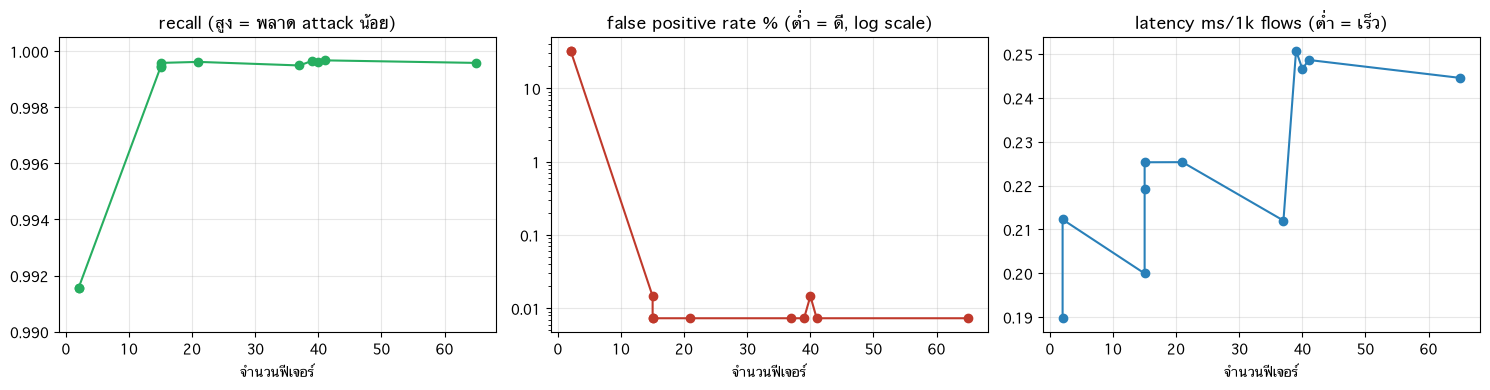

จุดซ้ายสุด (2 ฟีเจอร์) คือ intersection — FP พุ่งจนใช้ไม่ได้
ช่วง 15-65 ฟีเจอร์ recall แทบไม่ต่างกัน แต่ latency ต่างชัด


In [ ]:
# กราฟ: ลดฟีเจอร์แล้วแลกอะไร
from matplotlib.ticker import FuncFormatter, NullFormatter

d = st1.sort_values('n_features')
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(d['n_features'], d['recall'], marker='o', color='#27ae60')
axes[0].set_title('recall (สูง = พลาด attack น้อย)')
axes[0].set_ylim(0.99, 1.0005)

axes[1].plot(d['n_features'], d['fp_rate'] * 100, marker='o', color='#c0392b')
axes[1].set_yscale('log')
# tick ของแกน log ปกติเขียนเป็น 10^-1 ซึ่งใช้ mathtext (ระบบฟอนต์แยก)
# แล้วเครื่องหมายลบจะกลายเป็นสี่เหลี่ยม — เปลี่ยนเป็นตัวเลขธรรมดาแทน
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}'))
axes[1].yaxis.set_minor_formatter(NullFormatter())
axes[1].set_title('false positive rate % (ต่ำ = ดี, log scale)')

axes[2].plot(d['n_features'], d['latency_ms_per_1k'], marker='o', color='#2980b9')
axes[2].set_title('latency ms/1k flows (ต่ำ = เร็ว)')

for ax in axes:
    ax.set_xlabel('จำนวนฟีเจอร์')
    ax.grid(alpha=.3)

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'stage1_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print("จุดซ้ายสุด (2 ฟีเจอร์) คือ intersection — FP พุ่งจนใช้ไม่ได้")
print("ช่วง 15-65 ฟีเจอร์ recall แทบไม่ต่างกัน แต่ latency ต่างชัด")

## C2. ลดฟีเจอร์แล้วยังจับ attack ที่ไม่เคยเห็นได้ไหม

เทรนด้วย OVS → เทสด้วย metasploitable (คนละ testbed)
**U2R ไม่เคยอยู่ใน train เลย** = ทดสอบ zero-shot จริง

In [ ]:
zs = pd.read_csv(config.OUT_DIR / '05_zero_shot_per_class.csv')
display(zs.set_index('attack_class').round(4))

print("แถว U2R = คลาสที่ไม่เคยเทรน")
print("ถ้า recall ไม่ตกตอนลดฟีเจอร์ = การลดฟีเจอร์ไม่ทำลายความสามารถ generalize")

,เคยเห็น,n_test,all_features,attack7_dynamic,attack7_intersection,attack7_mean,attack7_union,binary_dynamic,binary_topk,normal8_dynamic,normal8_intersection,normal8_mean,normal8_union
attack_class,,,,,,,,,,,,,
BFA,ใช่,295,1.0000,1.0000,0.5051,1.0000,1.0000,1.0000,1.0000,1.0000,0.5051,1.0000,1.0000
DDoS,ใช่,73529,1.0000,1.0000,0.7275,0.9995,1.0000,1.0000,1.0000,1.0000,0.7275,1.0000,1.0000
DoS,ใช่,1145,0.7397,0.7563,0.0856,0.7336,0.7825,0.7616,0.7843,0.7555,0.0856,0.7825,0.7450
Probe,ใช่,61757,0.9994,0.9999,0.7558,0.9999,0.9999,0.9992,0.9999,0.9999,0.7558,0.9999,0.9999
U2R,ไม่ (zero-shot),17,0.9412,1.0000,0.5882,1.0000,1.0000,0.9412,1.0000,1.0000,0.5882,1.0000,1.0000


แถว U2R = คลาสที่ไม่เคยเทรน
ถ้า recall ไม่ตกตอนลดฟีเจอร์ = การลดฟีเจอร์ไม่ทำลายความสามารถ generalize


In [ ]:
# ผลรอง: stage 2 เองก็ลดฟีเจอร์ได้ไหม
st2 = pd.read_csv(config.OUT_DIR / '03_stage2_with_reduced_features.csv', index_col=0)
display(st2[['n_features', 'f1', 'f1_เทียบ_full_%']].round(4))

,n_features,f1,f1_เทียบ_full_%
attack7_intersection,2.0,0.7637,79.8572
normal8_intersection,2.0,0.7637,79.8572
attack7_mean,15.0,0.9377,98.0560
normal8_mean,15.0,0.9452,98.8398
binary_topk,15.0,0.9354,97.8121
binary_dynamic,21.0,0.9725,101.6959
attack7_union,37.0,0.9061,94.7504
normal8_union,39.0,0.9567,100.0392
attack7_dynamic,40.0,0.9421,98.5189
normal8_dynamic,41.0,0.9056,94.6978


---
# ส่วน D — วิธีอ่านกราฟ SHAP

ส่วน A–C ใช้ค่าเฉลี่ยของ SHAP ส่วนนี้ดูค่าดิบรายแถว จึงต้องคำนวณใหม่

In [ ]:
X_sample = X_train.sample(n=min(config.SHAP_SAMPLE, len(X_train)),
                          random_state=config.SEED)
explainer = shap.TreeExplainer(model)
sv = common.to_shap_array(explainer.shap_values(X_sample))
print('shape =', sv.shape, ' (samples, features, classes)')

shape = (5000, 65, 7)  (samples, features, classes)


## D1. Beeswarm — วิธีอ่าน

| องค์ประกอบ | ความหมาย |
|---|---|
| **ลำดับแกน Y** | เรียงตาม mean(\|SHAP\|) มาก→น้อย = ความสำคัญตัวจริง |
| **ตำแหน่งแกน X** | ค่า SHAP ของ *แต่ละแถวข้อมูล* หน่วยเป็น log-odds ไม่ใช่ probability<br>ขวา = ดันไปทาง "เป็นคลาสนี้" / ซ้าย = ดันออกจากคลาสนี้ |
| **สี** | ค่าดิบของฟีเจอร์นั้น — <span style="color:red">แดง = สูง</span>, <span style="color:blue">น้ำเงิน = ต่ำ</span> |
| **การกระจายแนวตั้ง** | jitter ล้วน ๆ **ไม่มีความหมายเชิงตัวเลข** แค่กันจุดทับกัน<br>แต่ *ความหนา* ของแถบบอกว่าจุดกระจุกตรงนั้นเยอะ |

**อ่านยังไงให้ได้ข้อสรุป:**
- แดงกองขวา / น้ำเงินกองซ้าย → ค่ายิ่งสูง ยิ่งเป็นคลาสนี้ (ความสัมพันธ์ทางเดียว)
- แดงกระจายทั้งสองฝั่ง → มี interaction กับฟีเจอร์อื่น ต้องดู dependence plot ต่อ
- จุดกระจุกที่ SHAP≈0 มีหางยาวไม่กี่จุด → สำคัญเฉพาะบางกรณี

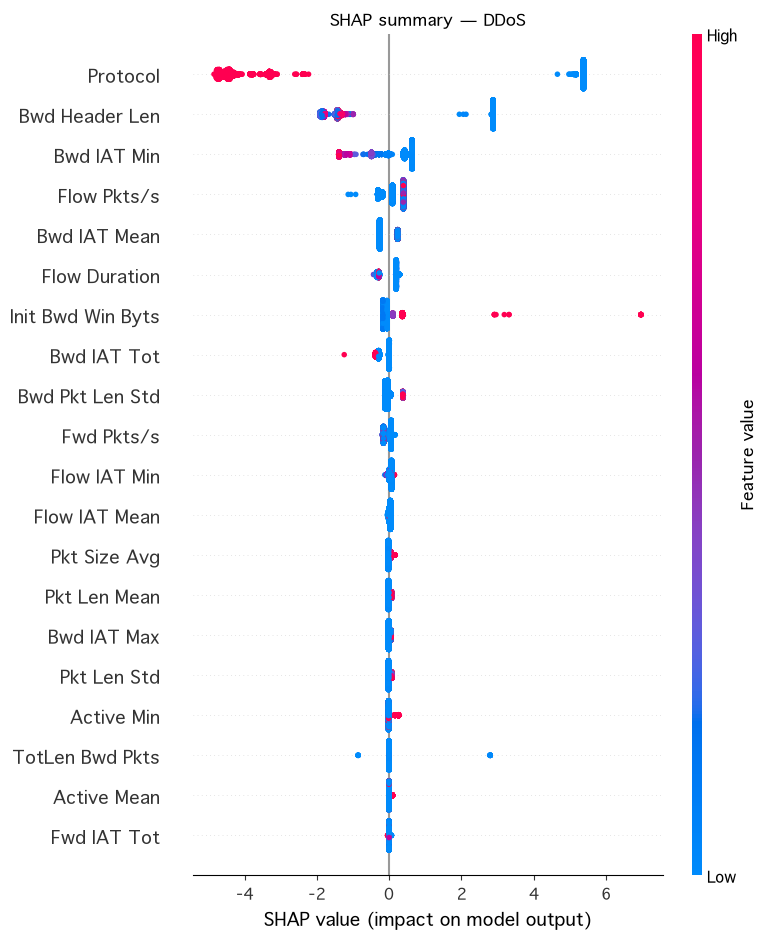

In [ ]:
CLASS = 'DDoS'   # <-- เปลี่ยนชื่อคลาสตรงนี้แล้วรันใหม่

idx = list(le.classes_).index(CLASS)
shap.summary_plot(sv[:, :, idx], X_sample, max_display=20, show=False)
plt.title(f'SHAP summary — {CLASS}')
plt.tight_layout()
plt.savefig(config.FIG_DIR / f'shap_beeswarm_{CLASS}.png', dpi=150, bbox_inches='tight')
plt.show()

## D2. Dependence plot — ฟีเจอร์เดียวส่งผลยังไง

แกน X = ค่าดิบของฟีเจอร์, แกน Y = SHAP ของฟีเจอร์นั้น

เส้นแนวโน้มชัด = ความสัมพันธ์ตรงไปตรงมา · กระจายเป็นแถบ = มี interaction

ฟีเจอร์สำคัญที่สุดของ DDoS: Protocol


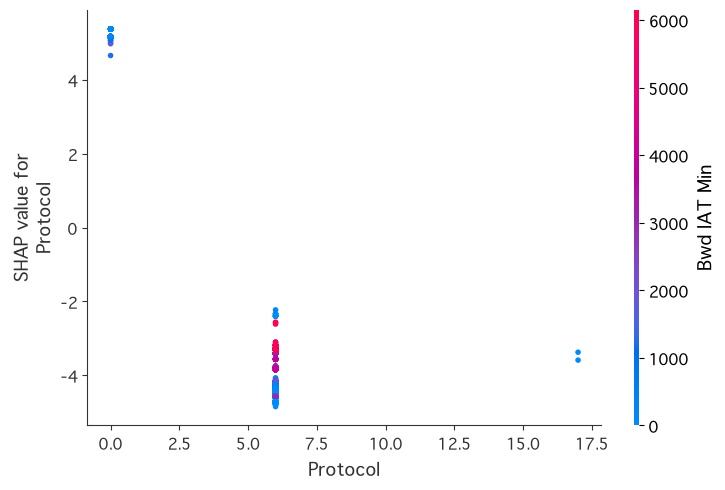

In [ ]:
FEATURE = imp[CLASS].idxmax()
print(f"ฟีเจอร์สำคัญที่สุดของ {CLASS}: {FEATURE}")

shap.dependence_plot(FEATURE, sv[:, :, idx], X_sample, show=False)
plt.tight_layout()
plt.savefig(config.FIG_DIR / f'shap_dependence_{CLASS}.png', dpi=150, bbox_inches='tight')
plt.show()

## D3. Waterfall — อธิบายทีละ 1 flow

ใช้ตอนต้องอธิบายว่า "ทำไม flow นี้ถึงถูกตัดสินแบบนั้น"

`E[f(x)]` = ค่าเฉลี่ยของ output ทั้ง dataset แล้วแต่ละฟีเจอร์ดันขึ้น/ลงจนได้ `f(x)`

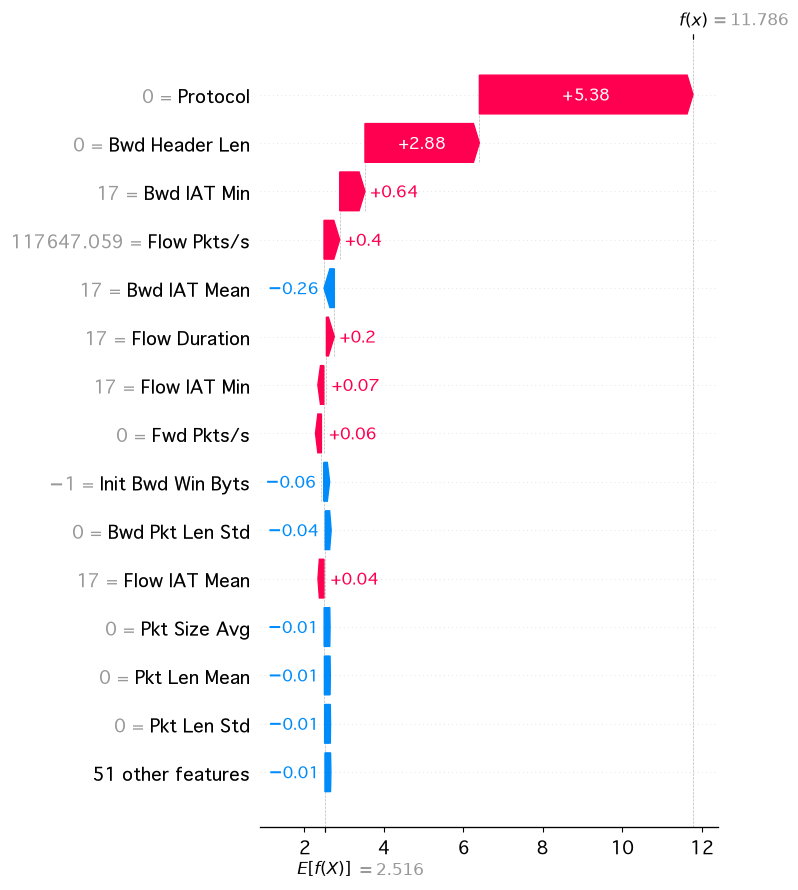

In [ ]:
ROW = 0   # เปลี่ยนเลขแถวได้

base = explainer.expected_value
base = base[idx] if np.ndim(base) > 0 else base

shap.plots.waterfall(
    shap.Explanation(values=sv[ROW, :, idx], base_values=base,
                     data=X_sample.iloc[ROW].values,
                     feature_names=list(X_sample.columns)),
    max_display=15, show=False)
plt.tight_layout()
plt.savefig(config.FIG_DIR / f'shap_waterfall_{CLASS}_row{ROW}.png',
            dpi=150, bbox_inches='tight')
plt.show()